#### **Задание 6**

Пусть известно решение $u(x), x\in [0, 1]$ начально-краевой задачи

$$ \dfrac{\partial u}{\partial t} - \Delta u = 0 , \quad x \in [0,1] , \quad t \in [0, T]$$
с граничным условием Неймана (слева) и Дирихле (справа)
$$ 
-k(x) \dfrac{\partial u}{\partial x}(0,t) = 0 , \quad u(1,t) = 0 , \quad 0 < t \le T
$$ 
$$
u(1,t) = \psi (t) , \quad t \in [0, T]
$$
с начальным условием
$$
u_0(x)= 0
$$
Дополнительная информация (граничное условие Дирихле на левом конце)
$$
u(0,t) = \phi (t) , \quad t \in [0,T]
$$
Необходимо восстановить функцию $\psi (t)$ при заданном возмущенном граничном условии слева $u(0,t) = \phi_\delta (x) , \, t \in [0,T]$ **с помощью метода возмущения нелокального граничного условия.**

Рассматривается сеточная задача c нелокальным граничным условием как регуляризация обратной задачи, $Au = \frac{\partial}{\partial x} (k(x) \frac{\partial u}{\partial x})$

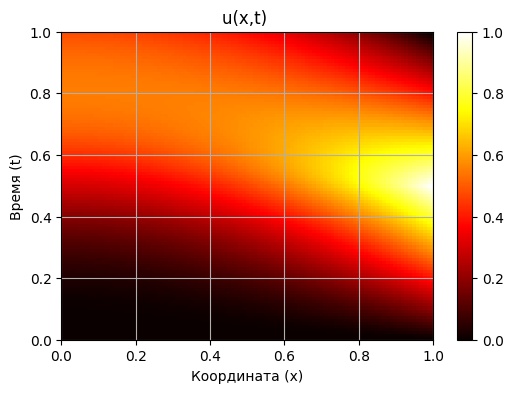

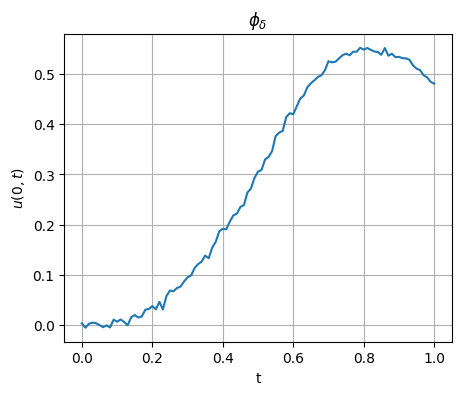

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def maps(value, titles):
    fig, ax1 = plt.subplots(figsize=(6, 4))
    im1 = ax1.imshow(value, extent=[ 0, Len, 0, T], aspect='auto', cmap='hot', origin='lower', interpolation='nearest')
    ax1.set_ylabel("Время (t)"); ax1.set_xlabel("Координата (x)"); ax1.set_title(f"{titles}(x,t) "); ax1.grid(True)
    fig.colorbar(im1, ax=ax1, orientation='vertical')
    plt.show()



Len = 1.0
N = 100
T = 1.0
M = 100
h = Len / N
tau = T / M
x = np.linspace(0,Len,N+1)
t = np.linspace(0,T,  M+1)

def psi(t):
    return (2 * t / T) if (t <= T/2) else (2 * (T - t) / T) 

A = -( 1 / h**2 )
B =  ( 2 / h**2 + 1 / tau)
C = -( 1 / h**2)

u = np.zeros((M+1,N+1))
u[0][:] = 0 

psi = np.array([psi(i) for i in t])

for j in range(M):
    alpha = np.zeros((N+1))
    beta = np.zeros((N+1))
    alpha[0] = 1
    beta[0] = 0
    # Прямой ход прогонки
    for i in range(0, N):
        alpha[i+1] = -C / (A * alpha[i] + B)
        beta[i+1] = (u[j,i]/tau - A * beta[i]) / (A * alpha[i] + B)
    u[j+1,N] = psi[j+1]
    for i in range(N-1, -1, -1):
        u[j+1][i] = alpha[i+1]*u[j+1][i+1] + beta[i+1]

phi = np.zeros(N+1)
for j in range(M+1):
    phi[j] = u[j][0]
maps(u, "u")
delta = 0.005
sigma = np.random.normal(0,1,size=(N+1))
phi_delta = phi + delta * sigma
plt.figure(figsize=(5,4))
plt.plot(t, phi_delta)
plt.title(f"$\phi_\delta$"); plt.ylabel("$u(0,t)$"); plt.xlabel("t"); plt.grid()
plt.show()


#### 
Восстановить функцию $ u_0(x) $ при заданном возмущенном решении $u(x, T) = \phi_\delta (x), x\in [0,1] $ , в финальным момент времени $ t = 0.1 $

* с помощью неявного итерационного метода

$$
B \dfrac{v_{k+1}-v_{k}}{s_{k+1}} + Av_k = \phi_\delta, \qquad B=E+\Lambda
$$


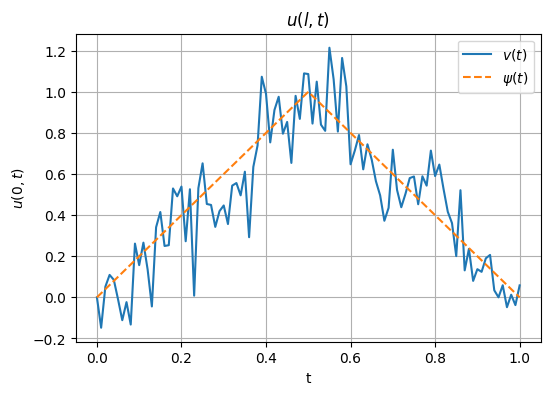

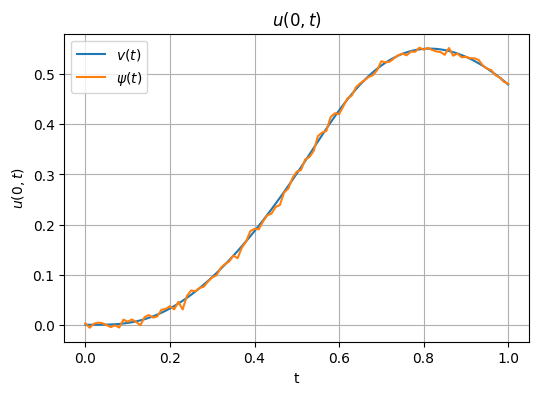

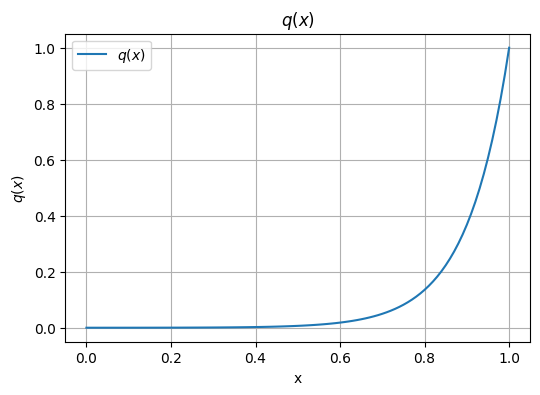

In [54]:
A = -( 1 / h**2 )
B = ( 2 / h**2 + 1 / tau)
C = -( 1 / h**2)

q = np.zeros(N+1)
qN = 1.0

alpha = np.zeros((N+1))
beta = np.zeros((N+1))
alpha[0] = 1
beta[0] = 0
# Прямой ход прогонки
for i in range(0, N):
    alpha[i+1] = -C / (A * alpha[i] + B)
    beta[i+1] = (- A * beta[i]) / (A * alpha[i] + B)
q[N] = qN
for i in range(N-1, -1, -1):
    q[i] = alpha[i+1]*q[i+1] + beta[i+1]


u_alpha = np.zeros((M+1, N+1))
alpha_const = 0.040
z = np.zeros((M+1, N+1))
v = np.zeros((M+1))
for j in range(M):
    alpha = np.zeros((N+1))
    beta = np.zeros((N+1))
    alpha[0] = 1
    beta[0] = 0
    # Прямой ход прогонки
    for i in range(0, N):
        alpha[i+1] = -C / (A * alpha[i] + B)
        beta[i+1] = ((u_alpha[j][i] - z[j+1][i]) / tau - A * beta[i]) / (A * alpha[i] + B)
    z[j+1,N] = 0.0
    for i in range(N-1, -1, -1):
        z[j+1][i] = alpha[i+1]*z[j+1][i+1] + beta[i+1]

    v[j+1] = ((phi_delta[j+1] - z[j+1][0]) / (alpha_const + q[0]))
    
    u_alpha[j+1] = z[j+1] + q*v[j+1]


plt.figure(figsize=(6,4))
plt.plot(t, v, label="$v(t)$")
plt.plot(t, psi,'--', label="$\psi(t)$")
plt.title(f"$u(l,t)$"); plt.ylabel("$u(0,t)$"); plt.xlabel("t"); plt.grid(); plt.legend()


plt.figure(figsize=(6,4))
plt.plot(t, phi, label="$v(t)$")
plt.plot(t, phi_delta, label="$\psi(t)$")
plt.title(f"$u(0,t)$"); plt.ylabel("$u(0,t)$"); plt.xlabel("t"); plt.grid(); plt.legend()


plt.figure(figsize=(6,4))
plt.plot(x, q, label="$q(x)$")
plt.title(f"$q(x)$"); plt.ylabel("$q(x)$"); plt.xlabel("x"); plt.grid(); plt.legend()
plt.show()


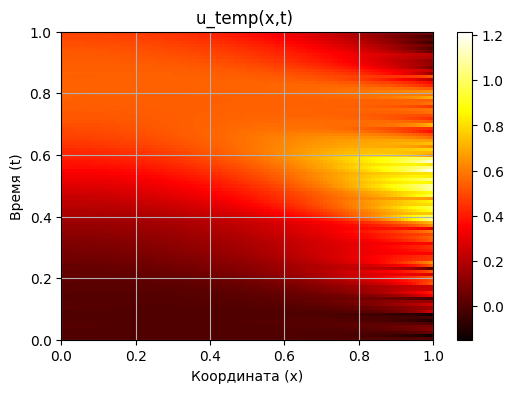

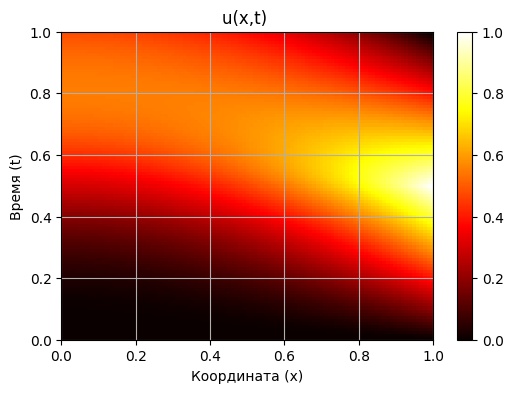

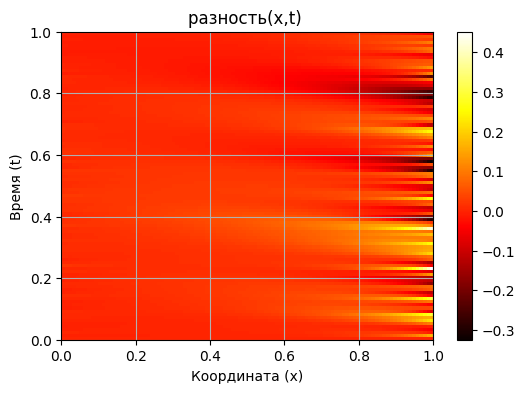

In [56]:
u_temp = np.zeros((M+1,N+1))
u_temp[0][:] = 0 
for j in range(M):
    alpha = np.zeros((N+1))
    beta = np.zeros((N+1))
    alpha[0] = 0
    beta[0] = phi_delta[j]
    # Прямой ход прогонки
    for i in range(0, N):
        alpha[i+1] = -C / (A * alpha[i] + B)
        beta[i+1] = (u_temp[j,i]/tau - A * beta[i]) / (A * alpha[i] + B)
    u_temp[j+1,N] = v[j+1]
    for i in range(N-1, -1, -1):
        u_temp[j+1][i] = alpha[i+1]*u_temp[j+1][i+1] + beta[i+1]
maps(u_temp, "u_temp")
maps(u, "u")
maps(u-u_temp, "разность")